# Głębokie Uczenie w Praktyce
## Laboratorium 7
### Mateusz Horczak

In [113]:
from numpy.exceptions import VisibleDeprecationWarning
import tensorflow as tf
import matplotlib.pyplot as plt
from random import randint
from numpy import array, argmax
from tensorflow.keras import preprocessing
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Embedding, SimpleRNN, Dense, Input
import warnings
warnings.filterwarnings("ignore", category=VisibleDeprecationWarning)

#### Ćwiczenie 1a Uruchomienie kodu z RNN - Echo sequence prediction problem - przygotowanie danych

In [114]:
# generate a sequence of random numbers in [0, n_features)
def generate_sequence(length, n_features):
    return [randint(0, n_features-1) for _ in range(length)]

# one hot encode sequence
def one_hot_encode(sequence, n_features):
    encoding = list()
    for value in sequence:
        vector = [0 for _ in range(n_features)]
        vector[value] = 1
        encoding.append(vector)
    return array(encoding)

# decode a one hot encoded string
def one_hot_decode(encoded_seq):
    return [argmax(vector) for vector in encoded_seq]

# generate one example for an lstm
def generate_example(length, n_features, out_index):
    sequence = generate_sequence(length, n_features)
    encoded = one_hot_encode(sequence, n_features)
    X = encoded.reshape((1, length, n_features))
    y = encoded[out_index].reshape(1, n_features)
    return X, y

In [115]:
seq1 = generate_sequence(5, 10)
print(seq1)

[5, 5, 9, 4, 8]


In [116]:
encoded_seq = one_hot_encode(seq1, 10)
print(encoded_seq)

[[0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]]


In [117]:
length = 5
n_features = 10
out_index = 3
X, y = generate_example(length, n_features, out_index)
print("X shape:", X.shape)
print("X:\n", X)
print("y shape:", y.shape)
print("y:\n", y)
print("Decoded expected output:", one_hot_decode(y))

X shape: (1, 5, 10)
X:
 [[[0 0 0 0 1 0 0 0 0 0]
  [0 0 1 0 0 0 0 0 0 0]
  [0 1 0 0 0 0 0 0 0 0]
  [1 0 0 0 0 0 0 0 0 0]
  [0 0 0 0 1 0 0 0 0 0]]]
y shape: (1, 10)
y:
 [[1 0 0 0 0 0 0 0 0 0]]
Decoded expected output: [np.int64(0)]


#### Ćwiczenie 1b

In [118]:
length = 5
n_features = 10
out_index = 2

# Budowa modelu LSTM
model = Sequential()
model.add(Input(shape=(length, n_features)))
model.add(LSTM(25))
model.add(Dense(n_features, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

Model: "sequential_110"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 25)             │         3,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 10)             │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,860 (15.08 KB)

 Trainable params: 3,860 (15.08 KB)

 Non-trainable params: 0 (0.00 B)

In [119]:
# Trening
for i in range(100):
    X, y = generate_example(length, n_features, out_index)
    model.fit(X, y, epochs=1, verbose=0)
    if (i + 1) % 10 == 0:
        print(f'Epoka: {i + 1}')

Epoka: 10
Epoka: 20
Epoka: 30
Epoka: 40
Epoka: 50
Epoka: 60
Epoka: 70
Epoka: 80
Epoka: 90
Epoka: 100


In [120]:
# Ewaluacja
correct = 0
for i in range(100):
    X, y = generate_example(length, n_features, out_index)
    X = tf.cast(X, tf.float32)
    yhat = model.predict(X, verbose=0)
    if one_hot_decode(yhat) == one_hot_decode(y):
        correct += 1
print('Accuracy: %.2f%%' % ((correct / 100.0) * 100))

Accuracy: 21.00%


In [121]:
# Predykcja
X, y = generate_example(length, n_features, out_index)
X = tf.cast(X, tf.float32)
yhat = model.predict(X, verbose=0)
print('Predykcja na nowych danych:')
seq_decoded = [int(x) for x in one_hot_decode(X[0])]
print('Sequence:', seq_decoded)
print('Expected:', int(one_hot_decode(y)[0]))
print('Predicted:', int(one_hot_decode(yhat)[0]))

Predykcja na nowych danych:
Sequence: [3, 3, 5, 9, 7]
Expected: 5
Predicted: 5


#### Ćwiczenie 2

In [122]:
# Parametry
max_features = 10000
maxlen = 200
embedding_dim = 32

# Ładowanie danych IMDB
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)
x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

In [123]:
# return_sequences=True
model_true = Sequential()
model_true.add(Embedding(max_features, embedding_dim))
model_true.add(SimpleRNN(32, return_sequences=True))
model_true.add(Dense(1, activation='sigmoid'))
model_true.summary()

Model: "sequential_111"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_95 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_94 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [124]:
# return_sequences=False
model_false = Sequential()
model_false.add(Embedding(max_features, embedding_dim))
model_false.add(SimpleRNN(32, return_sequences=False))
model_false.add(Dense(1, activation='sigmoid'))
model_false.summary()

Model: "sequential_112"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_96 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_95 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [125]:
# SimpleRNN + Embedding
model = Sequential()
model.add(Embedding(max_features, embedding_dim))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary()

Model: "sequential_113"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_97 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_96 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_105 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [126]:
# Trening
history = model.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - acc: 0.6664 - loss: 0.6009 - val_acc: 0.7606 - val_loss: 0.5014
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.8307 - loss: 0.3979 - val_acc: 0.8184 - val_loss: 0.4325
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.8690 - loss: 0.3183 - val_acc: 0.8394 - val_loss: 0.3948
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.8988 - loss: 0.2555 - val_acc: 0.8386 - val_loss: 0.3933
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.9270 - loss: 0.1895 - val_acc: 0.8194 - val_loss: 0.4140
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.9518 - loss: 0.1333 - val_acc: 0.8430 - val_loss: 0.5017
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.9701 - loss: 0.0895 - val_acc: 0.8424 - val_loss: 0.4729
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - acc: 0.9809 - loss: 0.0592 - val_acc: 0.7660 - val_loss: 0.7162
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/

#### Automatyzacja różnych parametrów

In [127]:
results = []
for maxlen_test in [20, 50, 100, 200]:
    for emb_dim in [8, 32, 64]:
        x_train_pad = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen_test)
        model_test = Sequential()
        model_test.add(Embedding(max_features, emb_dim, input_length=maxlen_test))
        model_test.add(SimpleRNN(32))
        model_test.add(Dense(1, activation='sigmoid'))
        model_test.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
        history_test = model_test.fit(x_train_pad, y_train, epochs=5, batch_size=128, validation_split=0.2, verbose=0)
        final_val_acc = history_test.history['val_acc'][-1]
        results.append((maxlen_test, emb_dim, final_val_acc))
        print(f'maxlen={maxlen_test}, emb={emb_dim} → val_acc={final_val_acc:.4f}')
print(results)

/home/mateusz/PycharmProjects/GUwP/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


maxlen=20, emb=8 → val_acc=0.7286
maxlen=20, emb=32 → val_acc=0.7036
maxlen=20, emb=64 → val_acc=0.7002
maxlen=50, emb=8 → val_acc=0.7792
maxlen=50, emb=32 → val_acc=0.7852
maxlen=50, emb=64 → val_acc=0.7208
maxlen=100, emb=8 → val_acc=0.8410
maxlen=100, emb=32 → val_acc=0.8052
maxlen=100, emb=64 → val_acc=0.8150
maxlen=200, emb=8 → val_acc=0.8130
maxlen=200, emb=32 → val_acc=0.8192
maxlen=200, emb=64 → val_acc=0.7496
[(20, 8, 0.728600025177002), (20, 32, 0.7035999894142151), (20, 64, 0.7002000212669373), (50, 8, 0.77920001745224), (50, 32, 0.7851999998092651), (50, 64, 0.72079998254776), (100, 8, 0.8410000205039978), (100, 32, 0.8051999807357788), (100, 64, 0.8149999976158142), (200, 8, 0.8130000233650208), (200, 32, 0.8191999793052673), (200, 64, 0.7495999932289124)]


#### Ćwiczenie 3

In [128]:
# Model z LSTM zamiast SimpleRNN
model_lstm = Sequential()
model_lstm.add(Embedding(max_features, 32, input_length=200))
model_lstm.add(LSTM(32))
model_lstm.add(Dense(1, activation='sigmoid'))
model_lstm.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model_lstm.summary()

Model: "sequential_126"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_110 (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_118 (Dense)               │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [129]:
# Trening
history_lstm = model_lstm.fit(x_train, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

acc = history_lstm.history['acc']
val_acc = history_lstm.history['val_acc']
loss = history_lstm.history['loss']
val_loss = history_lstm.history['val_loss']
epochs = range(1, len(acc) + 1)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - acc: 0.6541 - loss: 0.6089 - val_acc: 0.7546 - val_loss: 0.4967
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.8274 - loss: 0.3941 - val_acc: 0.8380 - val_loss: 0.3856
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.8626 - loss: 0.3335 - val_acc: 0.8606 - val_loss: 0.3315
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.8780 - loss: 0.3000 - val_acc: 0.8706 - val_loss: 0.3197
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.8878 - loss: 0.2786 - val_acc: 0.8660 - val_loss: 0.3603
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.9064 - loss: 0.2379 - val_acc: 0.8730 - val_loss: 0.3331
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.9136 - loss: 0.2251 - val_acc: 0.8602 - val_loss: 0.3727
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - acc: 0.9226 - loss: 0.2052 - val_acc: 0.8498 - val_loss: 0.3362
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/

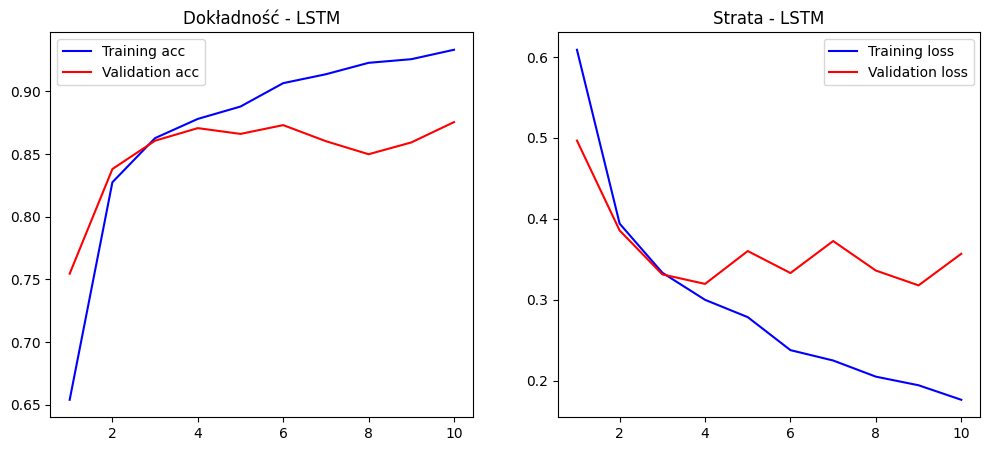

In [130]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Dokładność - LSTM')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Strata - LSTM')
plt.legend()
plt.show()

#### Ćwiczenie 4

In [131]:
# Test SimpleRNN
model_rnn = Sequential()
model_rnn.add(Input(shape=(10, 2)))
model_rnn.add(SimpleRNN(1))
model_rnn.summary()

Model: "sequential_127"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_109 (SimpleRNN)      │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [132]:
# Test LSTM
model_lstm_test = Sequential()
model_lstm_test.add(Input(shape=(10, 2)))
model_lstm_test.add(LSTM(1))
model_lstm_test.summary()

Model: "sequential_128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_18 (LSTM)                  │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

In [133]:
print("Wyjaśnienie input_shape=(10, 2):")
print("10 = liczba kroków czasowych (timesteps)")
print("2  = liczba cech na każdy krok czasowy (features)")

Wyjaśnienie input_shape=(10, 2):
10 = liczba kroków czasowych (timesteps)
2  = liczba cech na każdy krok czasowy (features)
